<a href="https://colab.research.google.com/github/edaska/Stochastic_Processes_-_Optimization_in_Machine_Learning/blob/main/lab2/Stochastic_Processes_%26_Optimization_in_Machine_Learning_(Lab_2_K_Means).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><b>The k-means Algorithm</b></h1> <p align="justify">In this exercise you will study the unsupervised learning algorithm <a href="https://en.wikipedia.org/wiki/K-means_clustering"><i>k-means</i></a> by developing a program. For this exercise you will use the <i>Scikit-Learn</i> library of <i>Python</i>. Specifically, you will classify 150 examples of the <i>Iris</i> plant, based on the unlabeled dataset provided at the end of the assignment. The <i>features</i> included in the <i>dataset</i> that describe each example are: <i>sepal length</i>, <i>sepal width</i>, <i>petal length</i>, and <i>petal width</i>.</p> <p>You are asked to do:</p> <ul> <li>Implement the <a href="https://en.wikipedia.org/wiki/Elbow_method_(clustering)"><i>“Elbow”</i></a> method on the Iris sample, in order to identify an adequate number of <i>clusters</i>. What do you observe?</li> <li>Implement the <i>k-means</i> algorithm based on the number of <i>clusters</i> you found in the previous question. Describe how the algorithm works.</li> <li>Evaluate the algorithm performance (<i>Accuracy</i>, <a href="https://en.wikipedia.org/wiki/Confusion_matrix"><i>Confusion Matrix values</i></a>).</li> </ul>

In [1]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.cluster import KMeans
import sklearn.metrics as sm

import pandas as pd
import numpy as np

In [2]:
# import some data to play with (from sklearn)
iris = datasets.load_iris()
print(iris)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

In [3]:
#print is optional
print(iris.data)
iris.feature_names
print(iris.target)
iris.target_names

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [6]:
# Store the inputs as a Pandas Dataframe and set the column names
x = pd.DataFrame(iris.data)
x.columns = ['Sepal_Length','Sepal_Width','Petal_Length','Petal_Width']

In [9]:
y = pd.DataFrame(iris.target)
y.columns = ['Targets']

In [14]:
print(x)

     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[150 rows x 4 columns]


In [15]:
print(y)

     Targets
0          0
1          0
2          0
3          0
4          0
..       ...
145        2
146        2
147        2
148        2
149        2

[150 rows x 1 columns]


In [19]:
X = x.values

In [21]:
print(X)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

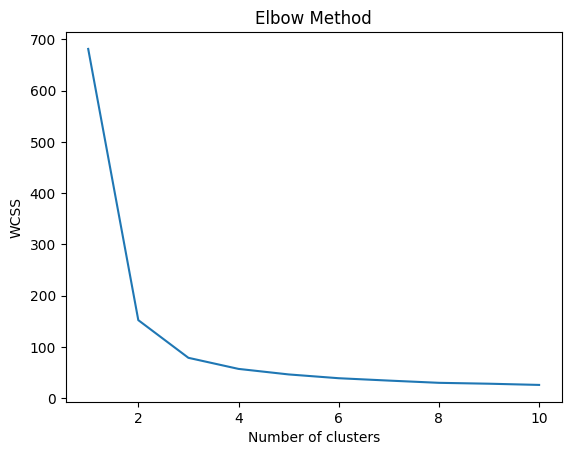

In [20]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++',
                    max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

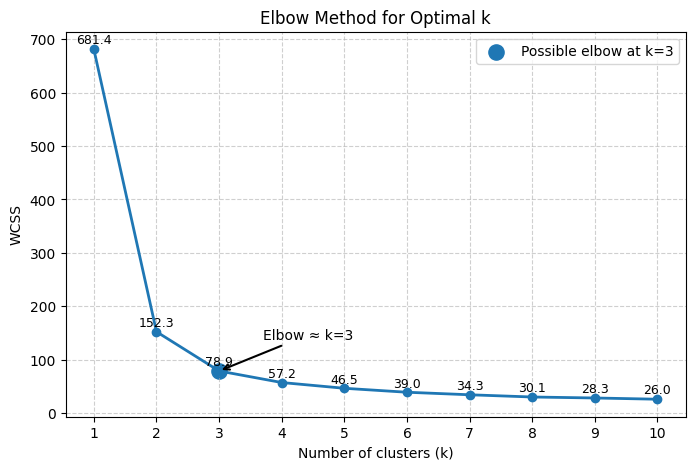

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=42
    )
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

k_values = range(1, 11)

plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker='o', linewidth=2)
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)

# highlight suspected elbow
elbow_k = 3
elbow_wcss = wcss[elbow_k - 1]

plt.scatter(elbow_k, elbow_wcss, s=120, label=f'Possible elbow at k={elbow_k}')
plt.annotate(
    f'Elbow ≈ k={elbow_k}',
    xy=(elbow_k, elbow_wcss),
    xytext=(elbow_k + 0.7, elbow_wcss + 60),
    arrowprops=dict(arrowstyle='->', lw=1.5),
    fontsize=10
)

# annotate all points
for k, val in zip(k_values, wcss):
    plt.text(k, val + 10, f'{val:.1f}', ha='center', fontsize=9)

plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.legend()
plt.show()

We observe that the WCSS drops rapidly until k = 3, and after that the decrease becomes much smaller and smoother. This means that adding more than 3 clusters does not significantly improve the clustering. Therefore, the elbow is at k = 3, so the optimal number of clusters is 3.

In [23]:
# For k=3
kmeans = KMeans(n_clusters=3, init="k-means++", n_init=10, random_state=42)
kmeans.fit(X)
print(f"{kmeans.inertia_:.2f}")

78.85


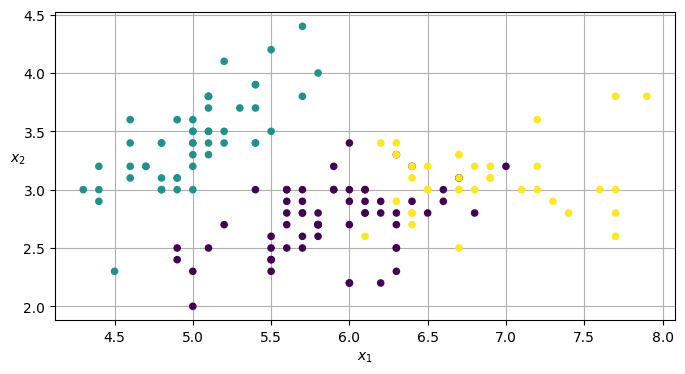

In [24]:
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap="viridis", s=20)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$", rotation=0)

plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.gca().set_axisbelow(True)
plt.grid()
plt.show()

Based on the Elbow method, we choose k = 3 and implement the K-means algorithm with 3 clusters. K-means begins with 3 initial centroids, then assigns each observation to the nearest centroid. Next, it recalculates each centroid as the mean of the points in its cluster. This assignment-and-update process is repeated until convergence. In this way, the algorithm groups the Iris samples into 3 clusters and minimizes the within-cluster sum of squares (WCSS).

In [27]:
X = iris.data
y_true = iris.target

In [29]:
print(X)
print(y_true)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [31]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score
from scipy.optimize import linear_sum_assignment

# cluster labels
y_pred = kmeans.labels_

# Confusion Matrix-like Tables
cm = confusion_matrix(y_true, y_pred)


row_ind, col_ind = linear_sum_assignment(-cm)
label_map = {col: row for row, col in zip(row_ind, col_ind)}

y_pred_aligned = np.array([label_map[label] for label in y_pred])

# -------------------------------
# 5. Final evaluation
# -------------------------------
final_cm = confusion_matrix(y_true, y_pred_aligned)
acc = accuracy_score(y_true, y_pred_aligned)

print("Cluster-to-class mapping:", label_map)
print("\nConfusion Matrix:")
print(pd.DataFrame(
    final_cm,
    index=["True Setosa", "True Versicolor", "True Virginica"],
    columns=["Pred Setosa", "Pred Versicolor", "Pred Virginica"]
))
print(f"\nAccuracy: {acc:.4f}")

Cluster-to-class mapping: {np.int64(1): np.int64(0), np.int64(0): np.int64(1), np.int64(2): np.int64(2)}

Confusion Matrix:
                 Pred Setosa  Pred Versicolor  Pred Virginica
True Setosa               50                0               0
True Versicolor            0               48               2
True Virginica             0               14              36

Accuracy: 0.8933


In [32]:
from sklearn.metrics import accuracy_score

# Evaluate label (test set ) accuracy of kNN classifier:
print(accuracy_score(y_true, y_pred_aligned))  # ορθότητα

0.8933333333333333


The algorithm was evaluated using the confusion matrix and accuracy. Because K-means assigns arbitrary cluster numbers, the predicted cluster labels were first matched to the true Iris labels. After alignment, the confusion matrix was computed to show the distribution of correct and incorrect assignments, and the accuracy was calculated as the percentage of correctly clustered samples. The results show that K-means with k = 3 achieves good clustering performance on the Iris dataset, with very strong separation for Setosa and some misclassifications between Versicolor and Virginica.